# AI vs Human Grading Analysis (Simple Steps)

1. Setup
2. Load data
3. Clean + rename columns
4. Descriptive summary + charts
5. Hypothesis tests
6. Ready-to-use conclusion

This notebook follows the report sections:

1. Introduction
2. Methodology
3. Data Processing
4. Data Analysis
5. Interpretation
6. Conclusion


In [36]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set significance level for all hypothesis tests
significance_level = 0.05
print("significance level =", significance_level)

significance level = 0.05


In [37]:
# Load survey data from Excel
data = pd.read_excel("Student Perceptions of AI vs. Human Grading (Responses) (1).xlsx")
data.head()

,Timestamp,Human_Fairness,AI_Fairness,AI_Bias_Concern,System_Preference,AI_Objectivity_Belief,Comfortable_AI_Grading_Aspects,Gender,Academic_Program,Year_of_Study
0,2026-04-07 09:12:09.582,2,2,3,Hybrid/AI Grading with Human Review (AI scores...,"Yes, AI is generally more objective",Multiple-choice quizzes,Male,Business Analytics,Year 2
1,2026-04-07 09:24:01.832,8,7,7,Hybrid/AI Grading with Human Review (AI scores...,Unsure,"Multiple-choice quizzes, Coding assignments",Female,Business Analytics,Year 2
2,2026-04-07 09:28:54.591,8,7,6,Hybrid/AI Grading with Human Review (AI scores...,Unsure,"Multiple-choice quizzes, Short answer question...",Male,Business Analytics,Year 2
3,2026-04-07 09:39:33.981,7,7,7,Hybrid/AI Grading with Human Review (AI scores...,"No, human grading is better or AI has new form...","Multiple-choice quizzes, Short answer question...",Male,Business Analytics,Year 2
4,2026-04-07 09:42:18.300,7,8,10,100% Human Grading (Traditional Teacher/Profes...,"Yes, AI is generally more objective",Multiple-choice quizzes,Male,Business Analytics,Year 2


In [38]:
# Quick structure check
print("shape:", data.shape)
print(data.columns)

shape: (91, 10)
Index(['Timestamp', 'Human_Fairness', 'AI_Fairness', 'AI_Bias_Concern',
       'System_Preference', 'AI_Objectivity_Belief',
       'Comfortable_AI_Grading_Aspects', 'Gender', 'Academic_Program',
       'Year_of_Study'],
      dtype='object')


In [39]:
# Remove timestamp column
data = data.drop(columns=["Timestamp"])

# Convert key numeric columns
cols = ["Human_Fairness", "AI_Fairness", "AI_Bias_Concern"]
data[cols] = data[cols].apply(pd.to_numeric)

# Remove duplicate responses
data = data.drop_duplicates()

# Standardize Academic_Program text
data["Academic_Program"] = data["Academic_Program"].str.strip().str.title()

print("clean shape:", data.shape)
print(data.isna().sum())
print(data["Academic_Program"].value_counts(dropna=False))

clean shape: (91, 9)
Human_Fairness                    0
AI_Fairness                       0
AI_Bias_Concern                   0
System_Preference                 0
AI_Objectivity_Belief             1
Comfortable_AI_Grading_Aspects    0
Gender                            0
Academic_Program                  0
Year_of_Study                     0
dtype: int64
Academic_Program
Business Analytics    48
Project Management    43
Name: count, dtype: int64


In [40]:
# Descriptive summary for main numeric variables
summary_cols = ["Human_Fairness", "AI_Fairness", "AI_Bias_Concern"]
print(data[summary_cols].describe().T[["count", "mean", "std", "min", "max"]])

                 count      mean       std  min   max
Human_Fairness    91.0  6.956044  2.366019  1.0  10.0
AI_Fairness       91.0  6.065934  2.303631  1.0  10.0
AI_Bias_Concern   91.0  6.219780  2.194955  1.0  10.0


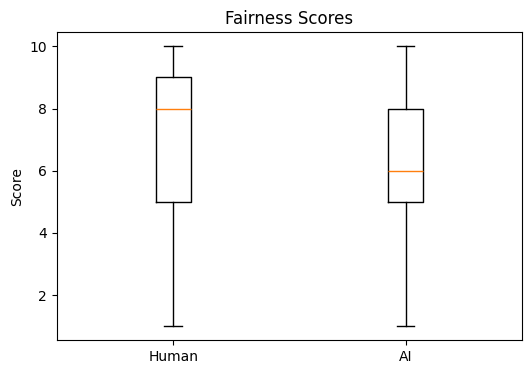

In [41]:
# Compare human vs AI fairness distributions
plt.figure(figsize=(6,4))
plt.boxplot([data["Human_Fairness"].dropna(), data["AI_Fairness"].dropna()], tick_labels=["Human", "AI"])
plt.title("Fairness Scores")
plt.ylabel("Score")
plt.show()

Human     39
AI        11
Hybrid    41
Name: count, dtype: int64


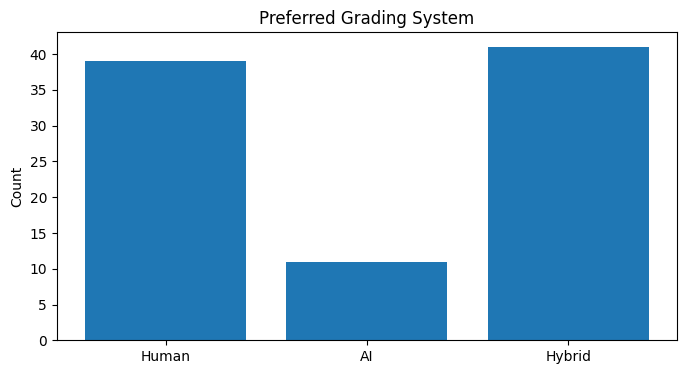

In [42]:
# Normalize full survey labels into Human / AI / Hybrid for plotting
pref_text = data["System_Preference"].fillna("").astype(str).str.strip().str.lower()

pref_group = np.select(
    [pref_text.str.contains("hybrid"), pref_text.str.contains("human"), pref_text.str.contains("100% ai|ai grading")],
    ["Hybrid", "Human", "AI"],
    default="Other"
)

pref = pd.Series(pref_group).value_counts().reindex(["Human", "AI", "Hybrid"], fill_value=0)
print(pref)

plt.figure(figsize=(8,4))
plt.bar(pref.index, pref.values)
plt.title("Preferred Grading System")
plt.ylabel("Count")
plt.show()

In [43]:
# Build paired dataset for within-student fairness comparison
paired = data[["Human_Fairness", "AI_Fairness"]].dropna()
paired = paired.assign(diff=paired["Human_Fairness"] - paired["AI_Fairness"])
print("paired n =", len(paired))

paired n = 91


In [44]:
# Paired t-test: same students rate Human and AI fairness
t_stat, p_value = stats.ttest_rel(paired["Human_Fairness"], paired["AI_Fairness"])

# Confidence interval for mean difference (Human - AI)
m = paired["diff"].mean()
s = paired["diff"].std(ddof=1)
se = s / np.sqrt(len(paired))
t_crit = stats.t.ppf(1 - significance_level / 2, len(paired) - 1)
ci_low = m - t_crit * se
ci_high = m + t_crit * se
decision = np.array(["Fail to reject H0", "Reject H0"])[int(p_value < significance_level)]

print("t =", round(t_stat, 4), "p =", round(p_value, 6))
print("95% CI:", round(ci_low, 3), round(ci_high, 3))
print("Decision:", decision)

t = 2.615 p = 0.010461
95% CI: 0.214 1.566
Decision: Reject H0


## Additional Analysis (By Academic Program)

**Test 2: Chi-square test of independence**

Research question: Is preferred grading system associated with academic program?

- H0: Academic_Program and Preferred Grading System are independent.
- H1: Academic_Program and Preferred Grading System are associated.


In [45]:
# Test 2: Chi-square test (Academic_Program vs Preferred Grading System)
prog_data = data[data["Academic_Program"].isin(["Business Analytics", "Project Management"])].copy()

# Group long preference text into Human / AI / Hybrid
pref_text = prog_data["System_Preference"].fillna("").astype(str).str.strip().str.lower()
prog_data["Preference_Group"] = np.select(
    [pref_text.str.contains("hybrid"), pref_text.str.contains("human"), pref_text.str.contains("100% ai|ai grading")],
    ["Hybrid", "Human", "AI"],
    default="Other"
)

# Build contingency table and run chi-square test
ct = pd.crosstab(prog_data["Academic_Program"], prog_data["Preference_Group"])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
chi_decision = "Reject H0" if p_chi < significance_level else "Fail to reject H0"

print("Chi-square test: Academic_Program vs Preferred Grading System")
print(ct)
print(f"chi2={chi2:.4f}, p={p_chi:.6f}, dof={dof}, decision={chi_decision}")

Chi-square test: Academic_Program vs Preferred Grading System
Preference_Group    AI  Human  Hybrid
Academic_Program                     
Business Analytics   5     20      23
Project Management   6     19      18
chi2=0.4529, p=0.797340, dof=2, decision=Fail to reject H0


Comfortable_AI_Grading_Aspects
Multiple-choice quizzes                    70
Short answer questions (factual recall)    38
Coding assignments                         35
Essays/Long-form written papers            28
Presentations/Oral assessments             15
Name: count, dtype: int64


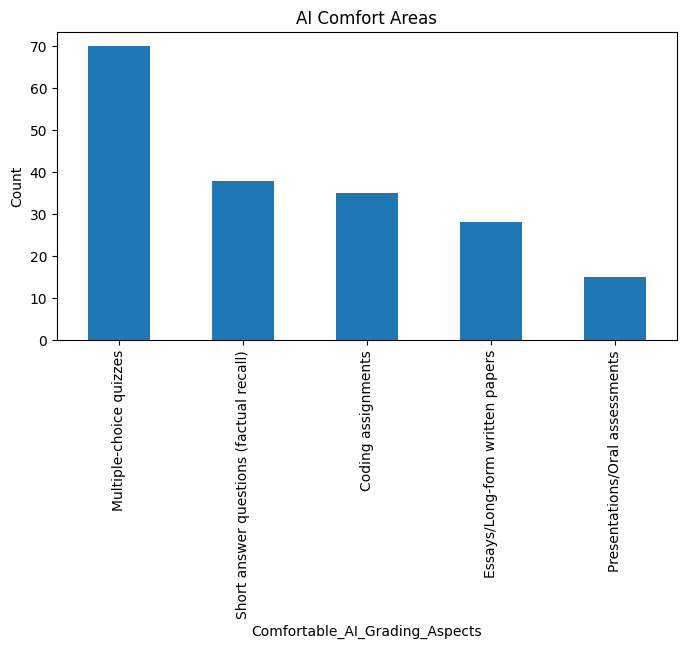

In [46]:
# Count selected comfort areas for AI grading
areas = data["Comfortable_AI_Grading_Aspects"].dropna().astype(str).str.split(",").explode().str.strip()
areas = areas[areas != ""]
count = areas.value_counts()
print(count)

count.plot(kind="bar", figsize=(8,4), title="AI Comfort Areas")
plt.ylabel("Count")
plt.show()

In [47]:
# Final summary values for report write-up
print("Mean Human Fairness =", round(paired["Human_Fairness"].mean(), 2))
print("Mean AI Fairness =", round(paired["AI_Fairness"].mean(), 2))
print("Paired t-test p-value =", round(p_value, 6))
print("Decision:", decision)
print("Significance level =", significance_level)

Mean Human Fairness = 6.96
Mean AI Fairness = 6.07
Paired t-test p-value = 0.010461
Decision: Reject H0
Significance level = 0.05


## Conclusion

Students rated human grading higher than AI grading in this sample. The paired t-test gives the main result for the hypothesis.


## Interpretation Notes (For Presentation)

1. This notebook uses only two hypothesis tests: paired t-test and chi-square.
2. For the chi-square test, p-value below 0.05 means grading preference is associated with academic program.
3. If p-value is above 0.05, there is no statistical evidence of association in this sample.
